# Import Librarys and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from imblearn.combine import SMOTETomek

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve



In [ ]:
data=pd.read_csv('/content/fetal_health.csv')

In [ ]:
pd.set_option('display.max_columns',None)

# Set colors

In [ ]:
custom_palette =["#1B263B","#34495E","#5DADE2","#85C1E9","#AED6F1"]
custom_palette2 =["#1B263B","#85C1E9"]

In [ ]:
from matplotlib.colors import ListedColormap
colors = [custom_palette[0], custom_palette[1],custom_palette[2],custom_palette[3]]

# EDA + Data Analysis

In [ ]:
data.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [ ]:
data.shape

(2126, 22)

In [ ]:
data.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [ ]:
data.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

**Missing Values**

In [ ]:
nulls=data.isnull().sum().sum()
print(f"Total Numbers of Null Values = {nulls} ")

Total Numbers of Null Values = 0 


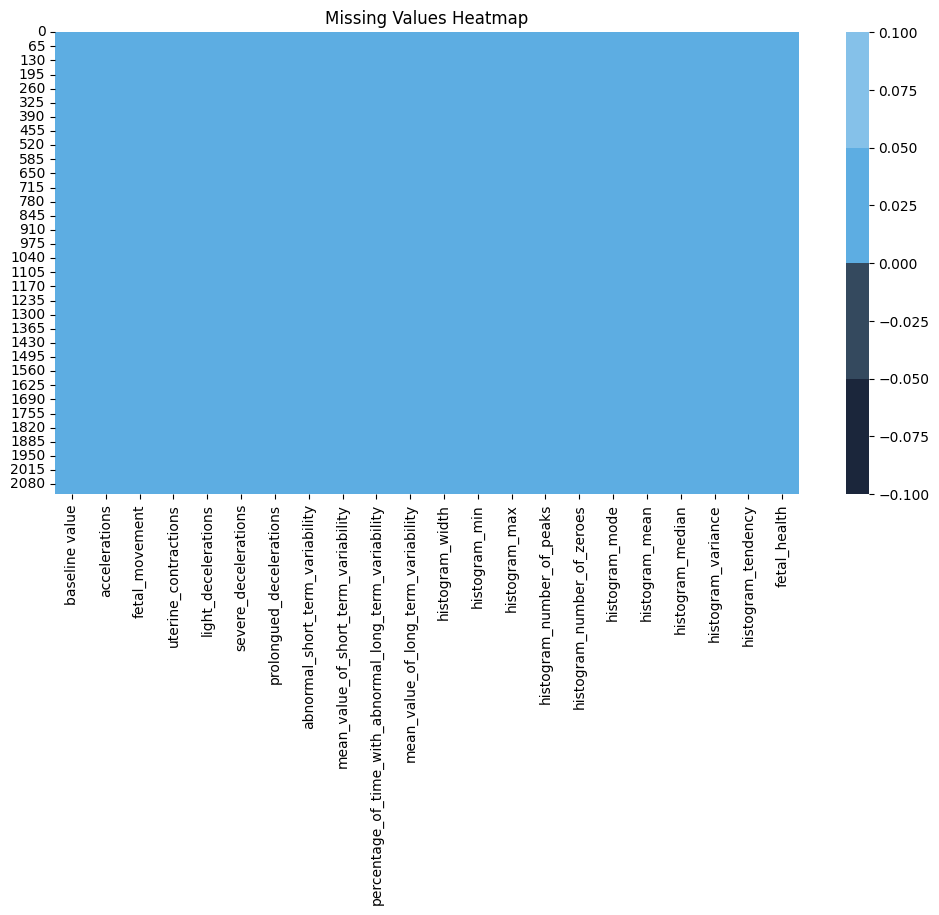

In [ ]:
plt.figure(figsize=(12,6))
cmap_custom = ListedColormap(colors)
sns.heatmap(data.isnull(), cmap=cmap_custom)
plt.title('Missing Values Heatmap')
plt.show()

 **duplicated Rows**

In [ ]:
dups=data.duplicated().sum()
print(f"Total Numbers of duplicated Rows = {dups} ")

Total Numbers of duplicated Rows = 13 


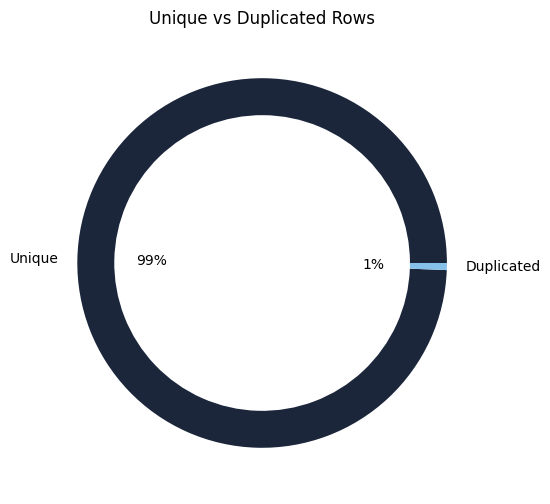

In [ ]:
unique = len(data) - dups
sizes = [unique, dups]
labels = ['Unique', 'Duplicated']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.0f%%', wedgeprops={'width':0.2}, colors=custom_palette2)
plt.title("Unique vs Duplicated Rows")
plt.show()

**Remove duplicated Rows**

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
dups=data.duplicated().sum()
print(f"Total Numbers of duplicated Rows = {dups} ")

Total Numbers of duplicated Rows = 0 


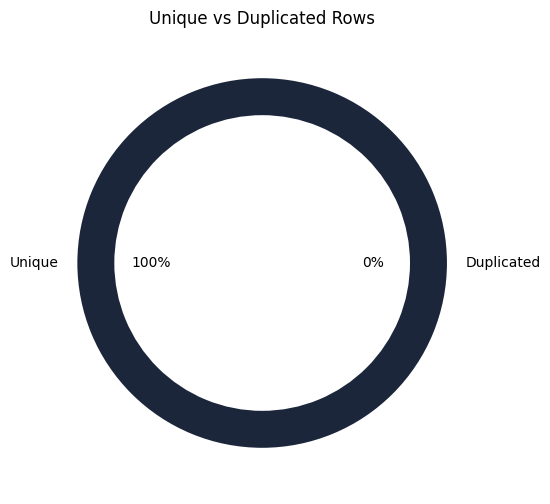

In [ ]:
unique = len(data) - dups
sizes = [unique, dups]
labels = ['Unique', 'Duplicated']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.0f%%', wedgeprops={'width':0.2}, colors=custom_palette)
plt.title("Unique vs Duplicated Rows")
plt.show()

**Feature Column**

In [ ]:
data['fetal_health'].unique()


array([2., 1., 3.])

In [ ]:
data['fetal_health'].value_counts()

,count
fetal_health,
1.0,1646
2.0,292
3.0,175


/tmp/ipython-input-3511439168.py:2: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(data=data, x='fetal_health', hue='fetal_health', palette=custom_palette, legend=False)


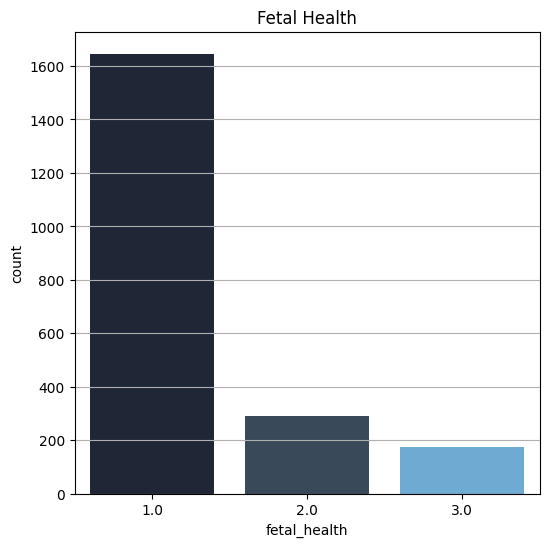

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(data=data, x='fetal_health', hue='fetal_health', palette=custom_palette, legend=False)
plt.grid(axis='y')
plt.title('Fetal Health')
plt.show()

**Correlation matrix**

In [ ]:
corr_matrix = data.corr()
corr_matrix

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
baseline value,1.000000,-0.081885,-0.033949,-0.149587,-0.159836,-0.053706,-0.105003,0.303502,-0.278344,0.283918,-0.028901,-0.147150,0.360129,0.273402,-0.113242,-0.004807,0.708074,0.722152,0.788487,-0.134458,0.294412,0.146077
accelerations,-0.081885,1.000000,0.048114,0.086174,-0.110595,-0.043237,-0.128682,-0.280495,0.206762,-0.373507,-0.141413,0.298350,-0.155306,0.392684,0.189209,-0.007360,0.243083,0.270266,0.272507,0.124433,0.030670,-0.363947
fetal_movement,-0.033949,0.048114,1.000000,-0.069867,0.048795,-0.011022,0.265802,-0.104876,0.121532,-0.074900,0.011749,0.162803,-0.154297,0.099703,0.164645,-0.018122,-0.061496,-0.089938,-0.072676,0.179115,-0.001459,0.088057
uterine_contractions,-0.149587,0.086174,-0.069867,1.000000,0.282325,0.006416,0.075533,-0.234868,0.289004,-0.306057,-0.061488,0.141496,-0.115445,0.117391,0.080074,0.054975,-0.107352,-0.189689,-0.143001,0.236030,-0.069177,-0.205117
light_decelerations,-0.159836,-0.110595,0.048795,0.282325,1.000000,0.107483,0.224888,-0.119912,0.562265,-0.271542,-0.241392,0.520556,-0.555570,0.216314,0.397093,0.233940,-0.348386,-0.528620,-0.389898,0.563352,0.001977,0.059651
severe_decelerations,-0.053706,-0.043237,-0.011022,0.006416,0.107483,1.000000,0.012303,0.034071,0.034046,-0.030804,-0.037537,0.044826,-0.072162,-0.021438,0.006866,0.043308,-0.215559,-0.158950,-0.160805,0.136356,-0.070501,0.132408
prolongued_decelerations,-0.105003,-0.128682,0.265802,0.075533,0.224888,0.012303,1.000000,0.046360,0.266867,-0.137477,-0.226067,0.265293,-0.277521,0.119492,0.222605,0.055714,-0.437339,-0.489557,-0.445847,0.502976,-0.215226,0.486752
abnormal_short_term_variability,0.303502,-0.280495,-0.104876,-0.234868,-0.119912,0.034071,0.046360,1.000000,-0.428973,0.456708,-0.314061,-0.263059,0.278249,-0.113436,-0.169837,-0.150083,0.055694,0.072018,0.117442,-0.147080,-0.010233,0.469671
mean_value_of_short_term_variability,-0.278344,0.206762,0.121532,0.289004,0.562265,0.034046,0.266867,-0.428973,1.000000,-0.469191,0.073986,0.662788,-0.625601,0.410118,0.502948,0.265669,-0.306681,-0.444696,-0.335175,0.555874,-0.062618,-0.101089
percentage_of_time_with_abnormal_long_term_variability,0.283918,-0.373507,-0.074900,-0.306057,-0.271542,-0.030804,-0.137477,0.456708,-0.469191,1.000000,-0.170590,-0.455015,0.427104,-0.285477,-0.279871,-0.121341,0.163879,0.221090,0.185019,-0.281714,0.037646,0.421634


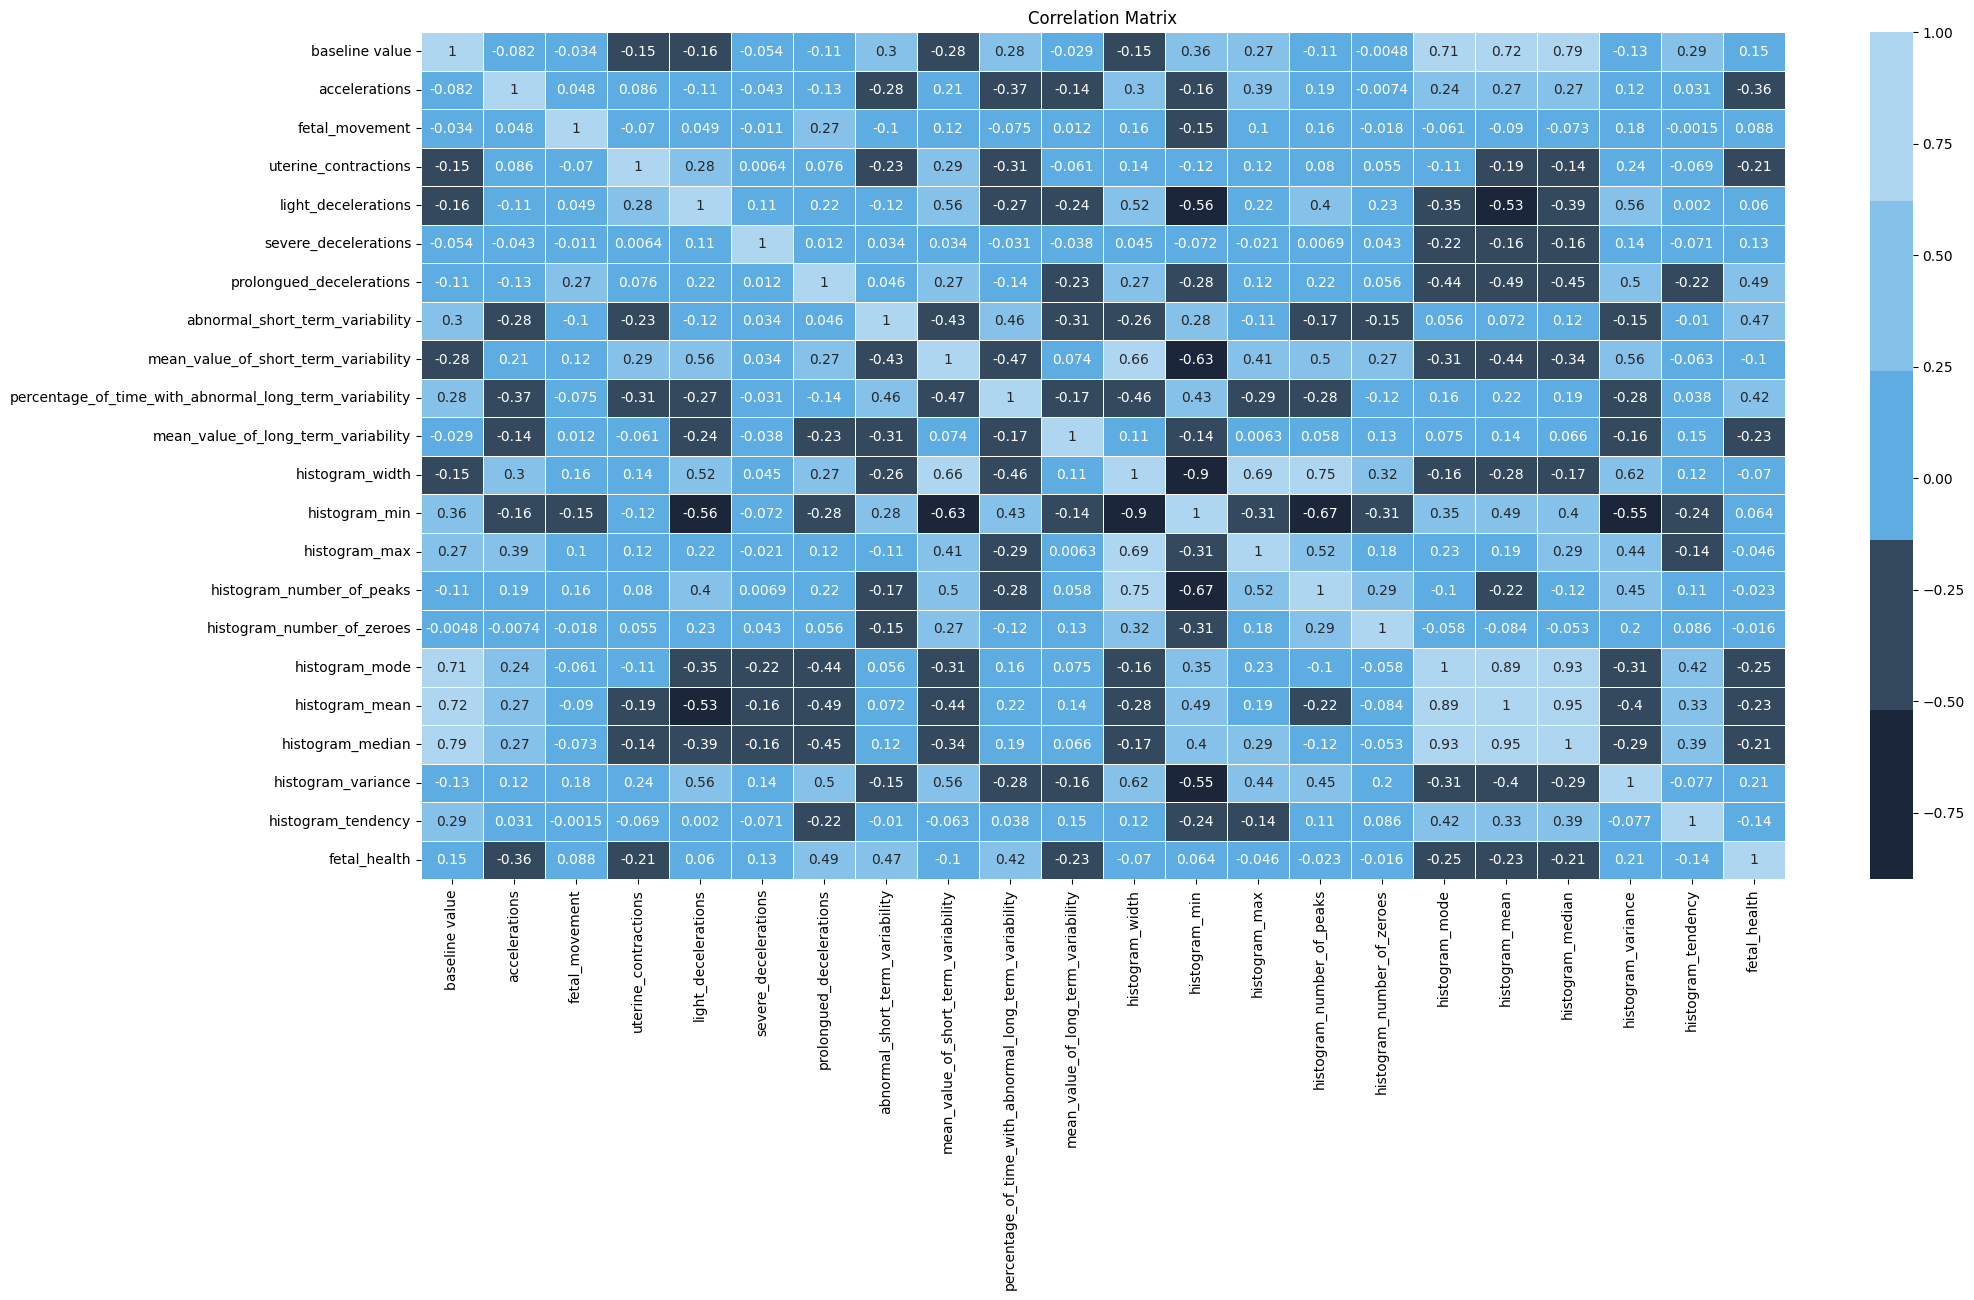

In [ ]:
plt.figure(figsize=(22,11))
sns.heatmap(corr_matrix, annot=True,linewidths=0.5,cmap=custom_palette)
plt.title('Correlation Matrix')
plt.show()

**top 9 features with postive correlation**

In [ ]:

frisy_features_P=corr_matrix['fetal_health'].sort_values(ascending=False)[1:10]
frisy_features_P

,fetal_health
prolongued_decelerations,0.486752
abnormal_short_term_variability,0.469671
percentage_of_time_with_abnormal_long_term_variability,0.421634
histogram_variance,0.208171
baseline value,0.146077
severe_decelerations,0.132408
fetal_movement,0.088057
histogram_min,0.063529
light_decelerations,0.059651


/tmp/ipython-input-1809271193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frisy_features_P.index, y=frisy_features_P.values, palette=custom_palette)
/tmp/ipython-input-1809271193.py:2: UserWarning: 
The palette list has fewer values (5) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=frisy_features_P.index, y=frisy_features_P.values, palette=custom_palette)


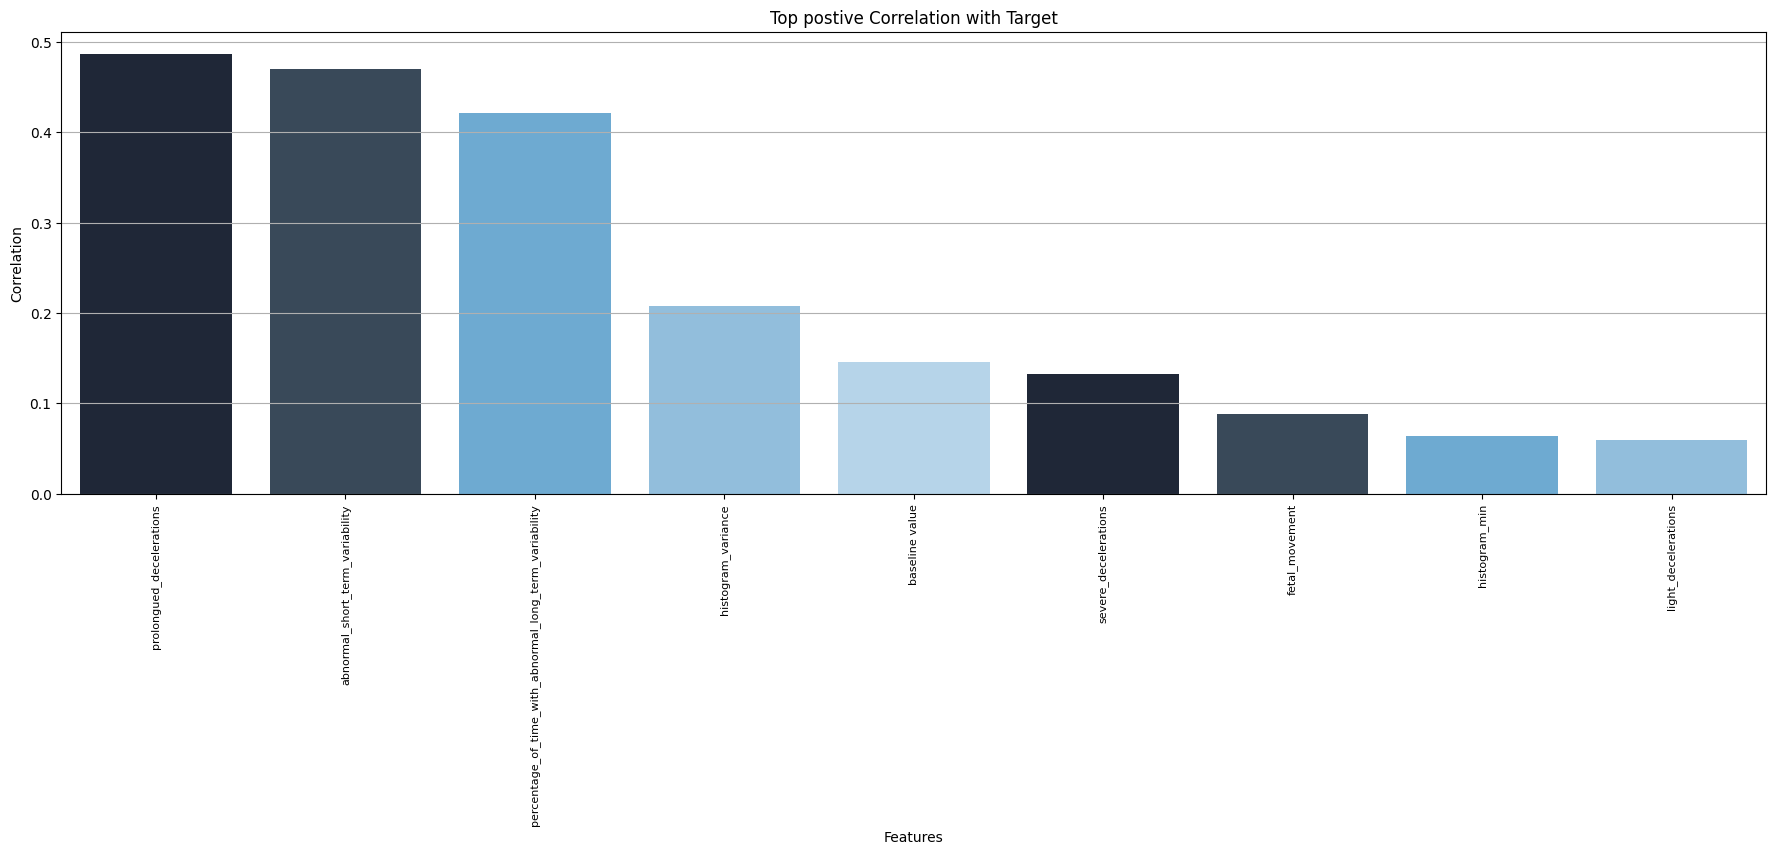

In [ ]:
plt.figure(figsize=(22,6))
sns.barplot(x=frisy_features_P.index, y=frisy_features_P.values, palette=custom_palette)
plt.grid(axis='y')
plt.xticks(rotation=90, fontsize=8)
plt.title('Top postive Correlation with Target')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()

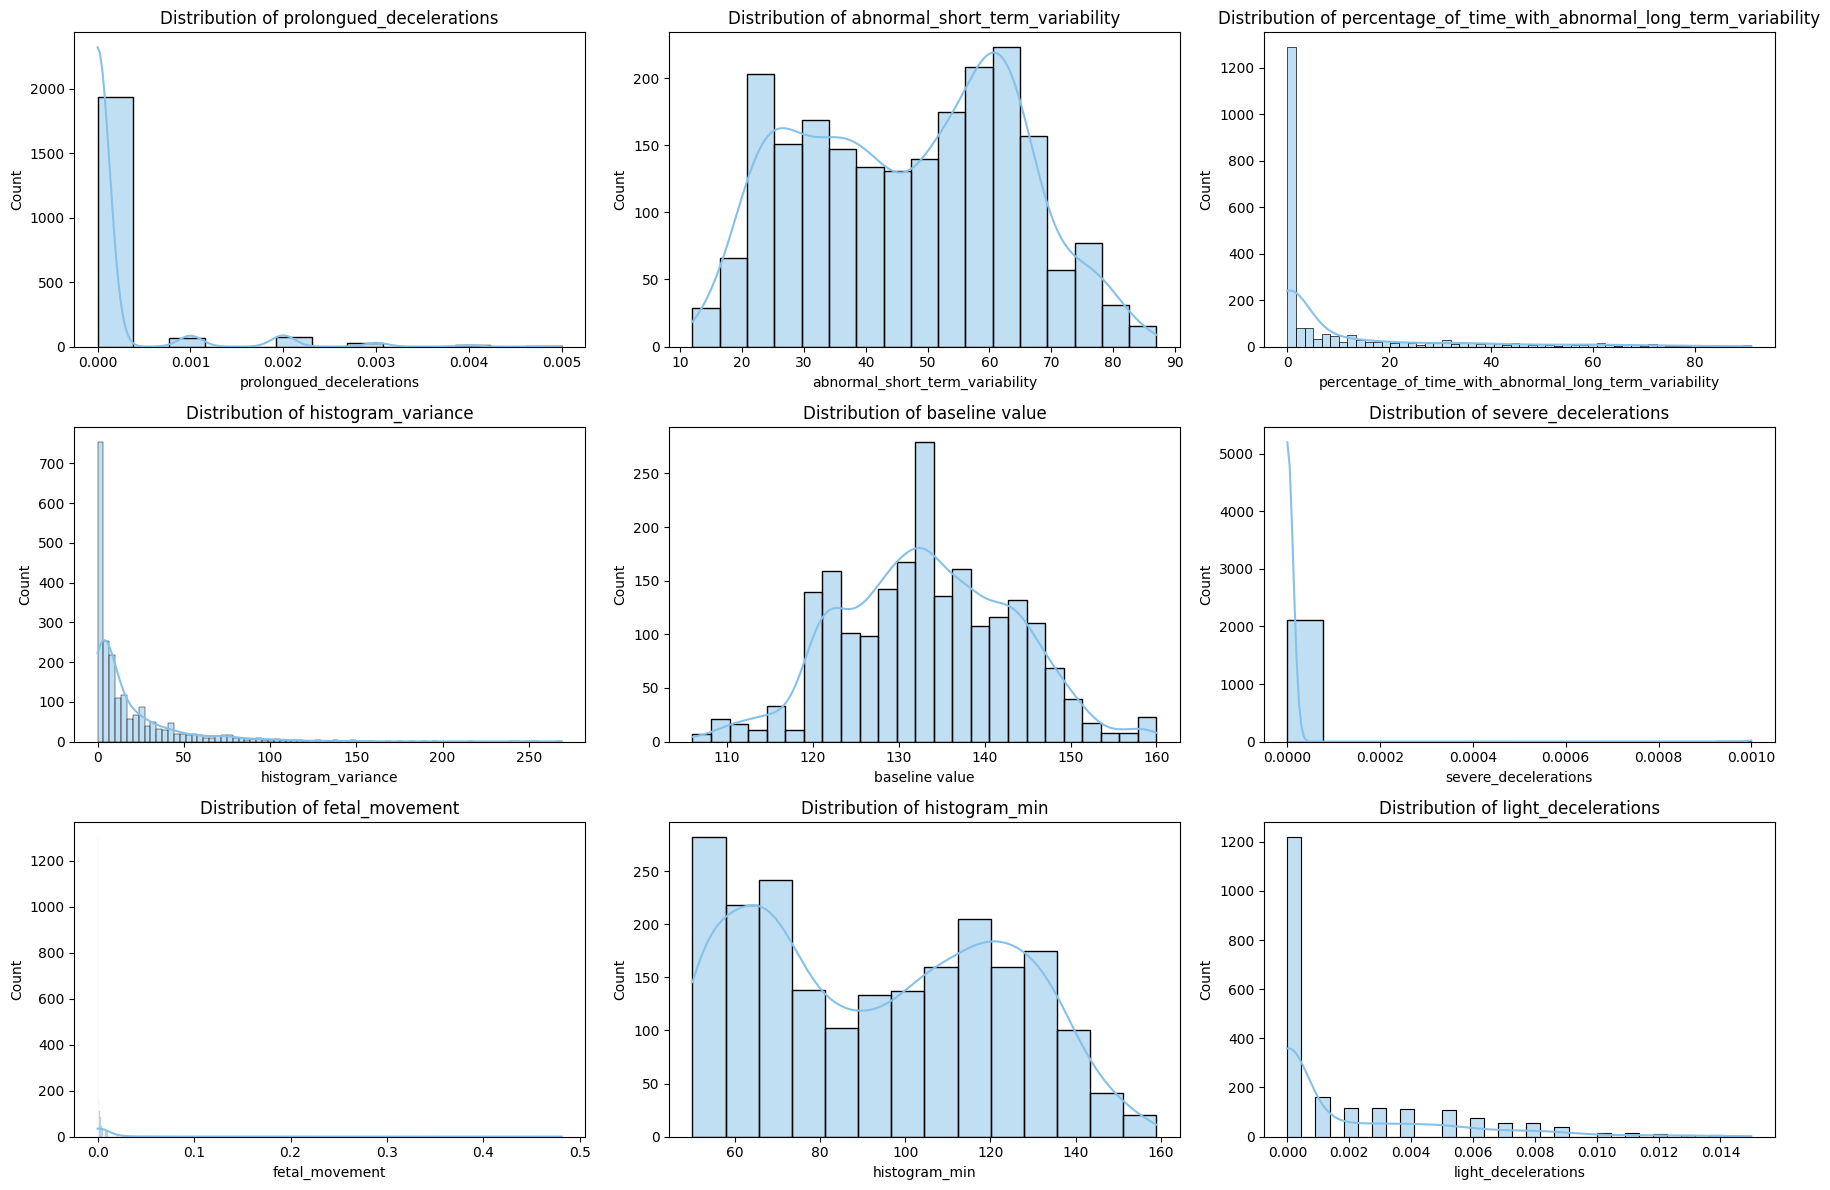

In [ ]:
cols = frisy_features_P.index
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color=custom_palette[3])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")


plt.tight_layout()
plt.show()


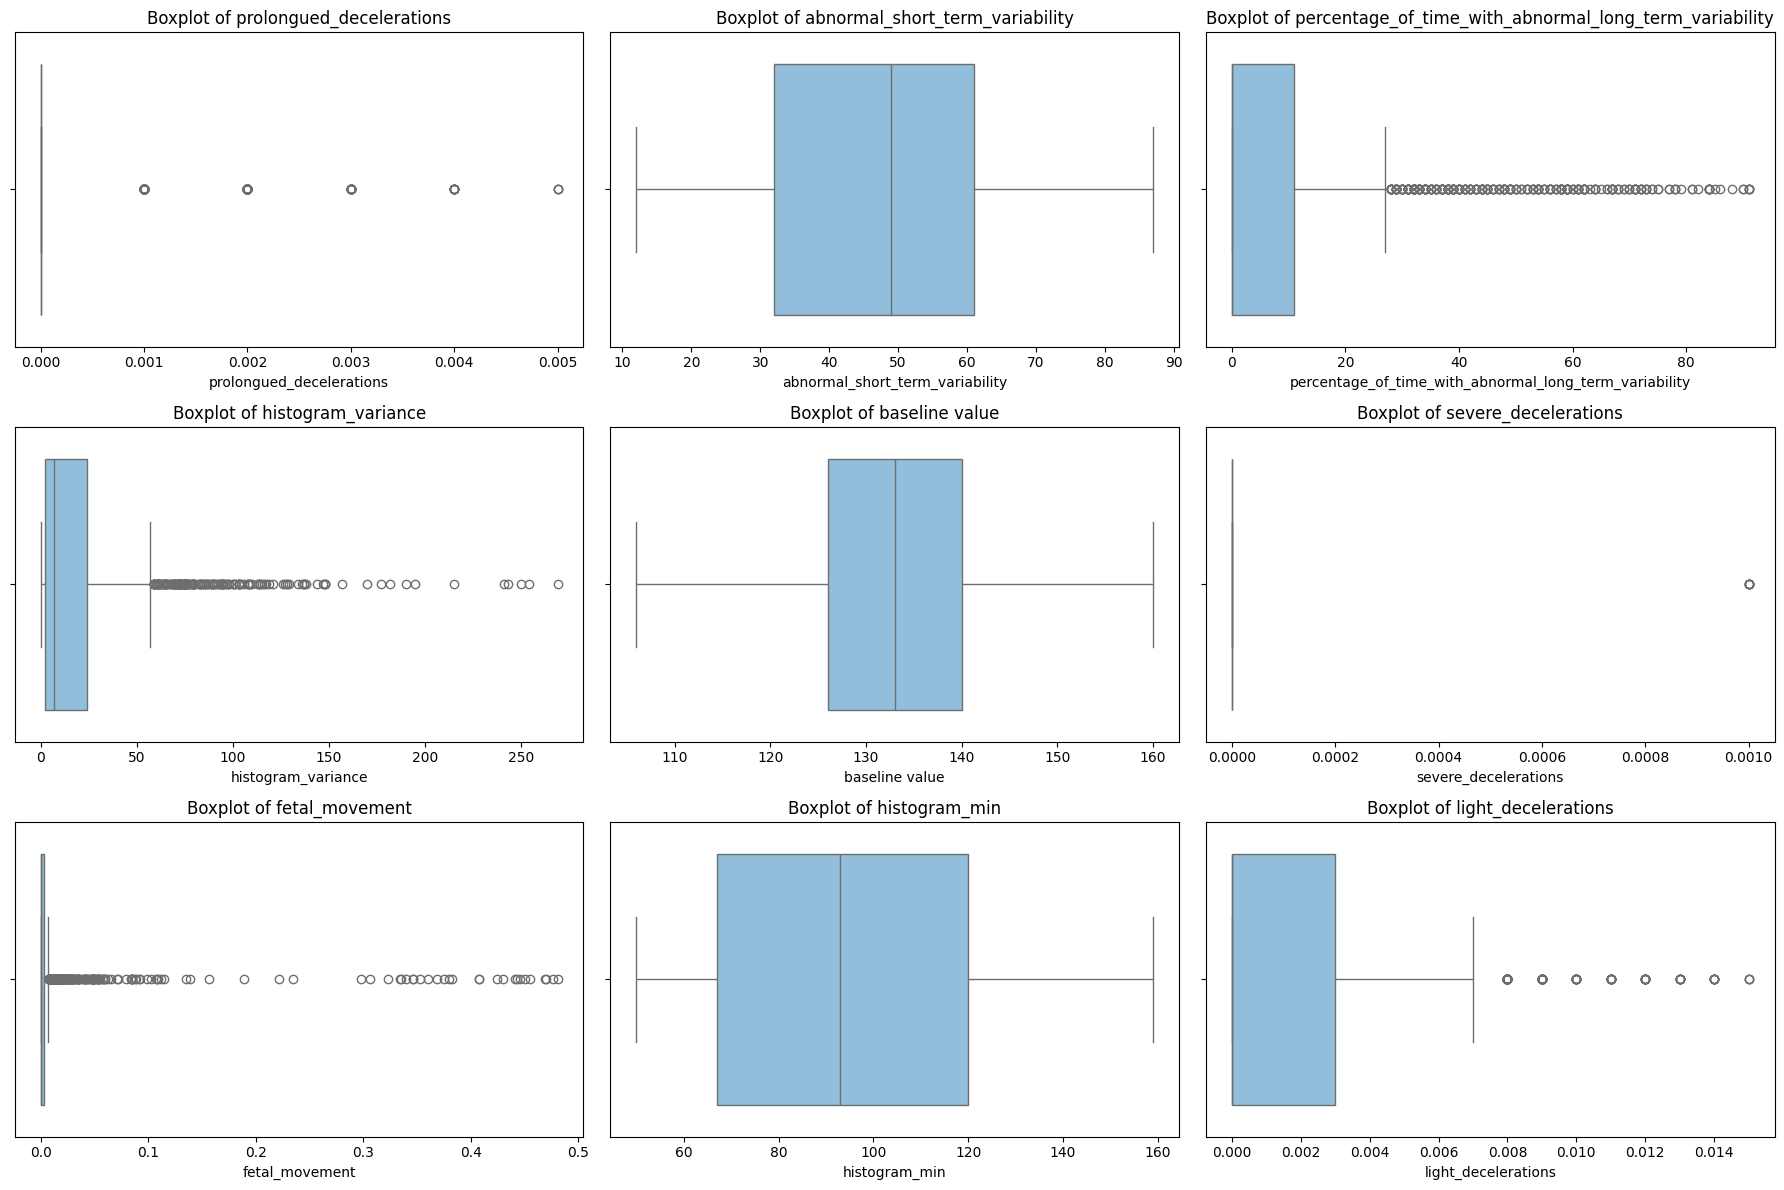

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(ax=axes[i], x=data[col], color=custom_palette[3])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

**top 9 features with Negative correlation**

In [ ]:
frisy_features_N=corr_matrix['fetal_health'].sort_values(ascending=True)[1:10]
frisy_features_N

,fetal_health
histogram_mode,-0.253612
histogram_mean,-0.230243
mean_value_of_long_term_variability,-0.225685
histogram_median,-0.208334
uterine_contractions,-0.205117
histogram_tendency,-0.135573
mean_value_of_short_term_variability,-0.101089
histogram_width,-0.069529
histogram_max,-0.046480


/tmp/ipython-input-3207789129.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frisy_features_N.index, y=frisy_features_N.values, palette=custom_palette)
/tmp/ipython-input-3207789129.py:2: UserWarning: 
The palette list has fewer values (5) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=frisy_features_N.index, y=frisy_features_N.values, palette=custom_palette)


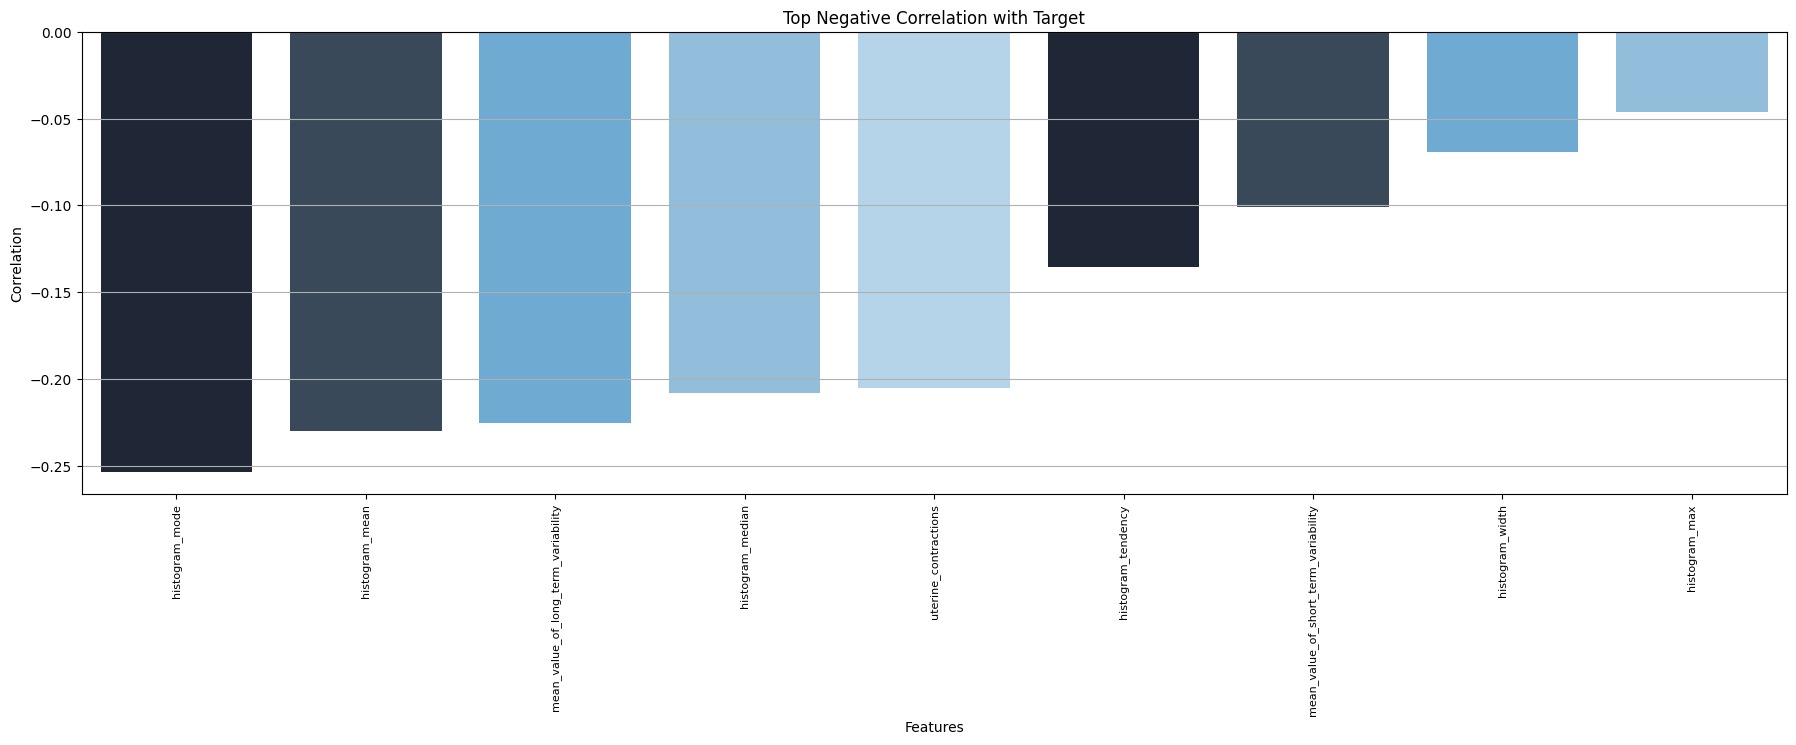

In [ ]:
plt.figure(figsize=(22,6))
sns.barplot(x=frisy_features_N.index, y=frisy_features_N.values, palette=custom_palette)
plt.grid(axis='y')
plt.xticks(rotation=90, fontsize=8)
plt.title('Top Negative Correlation with Target')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()

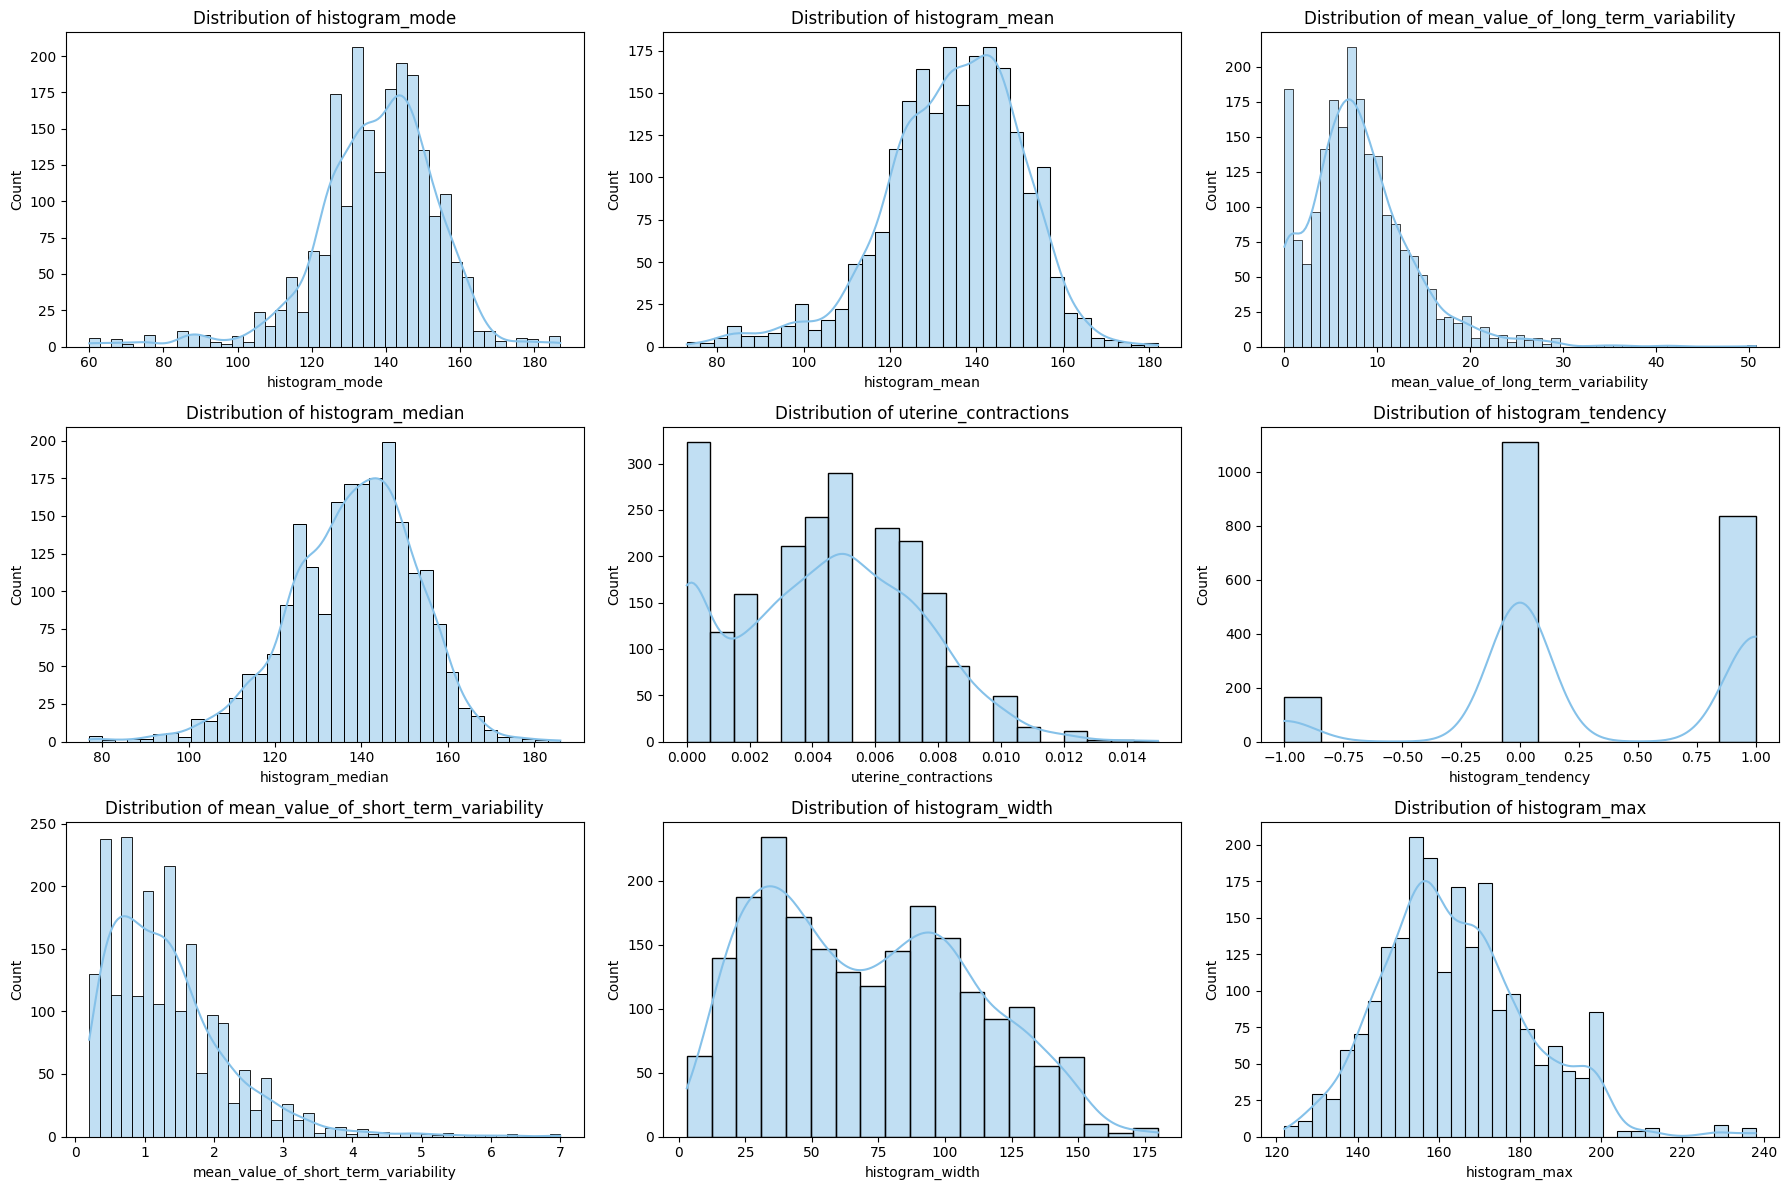

In [ ]:
cols = frisy_features_N.index
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color=custom_palette[3])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")


plt.tight_layout()
plt.show()


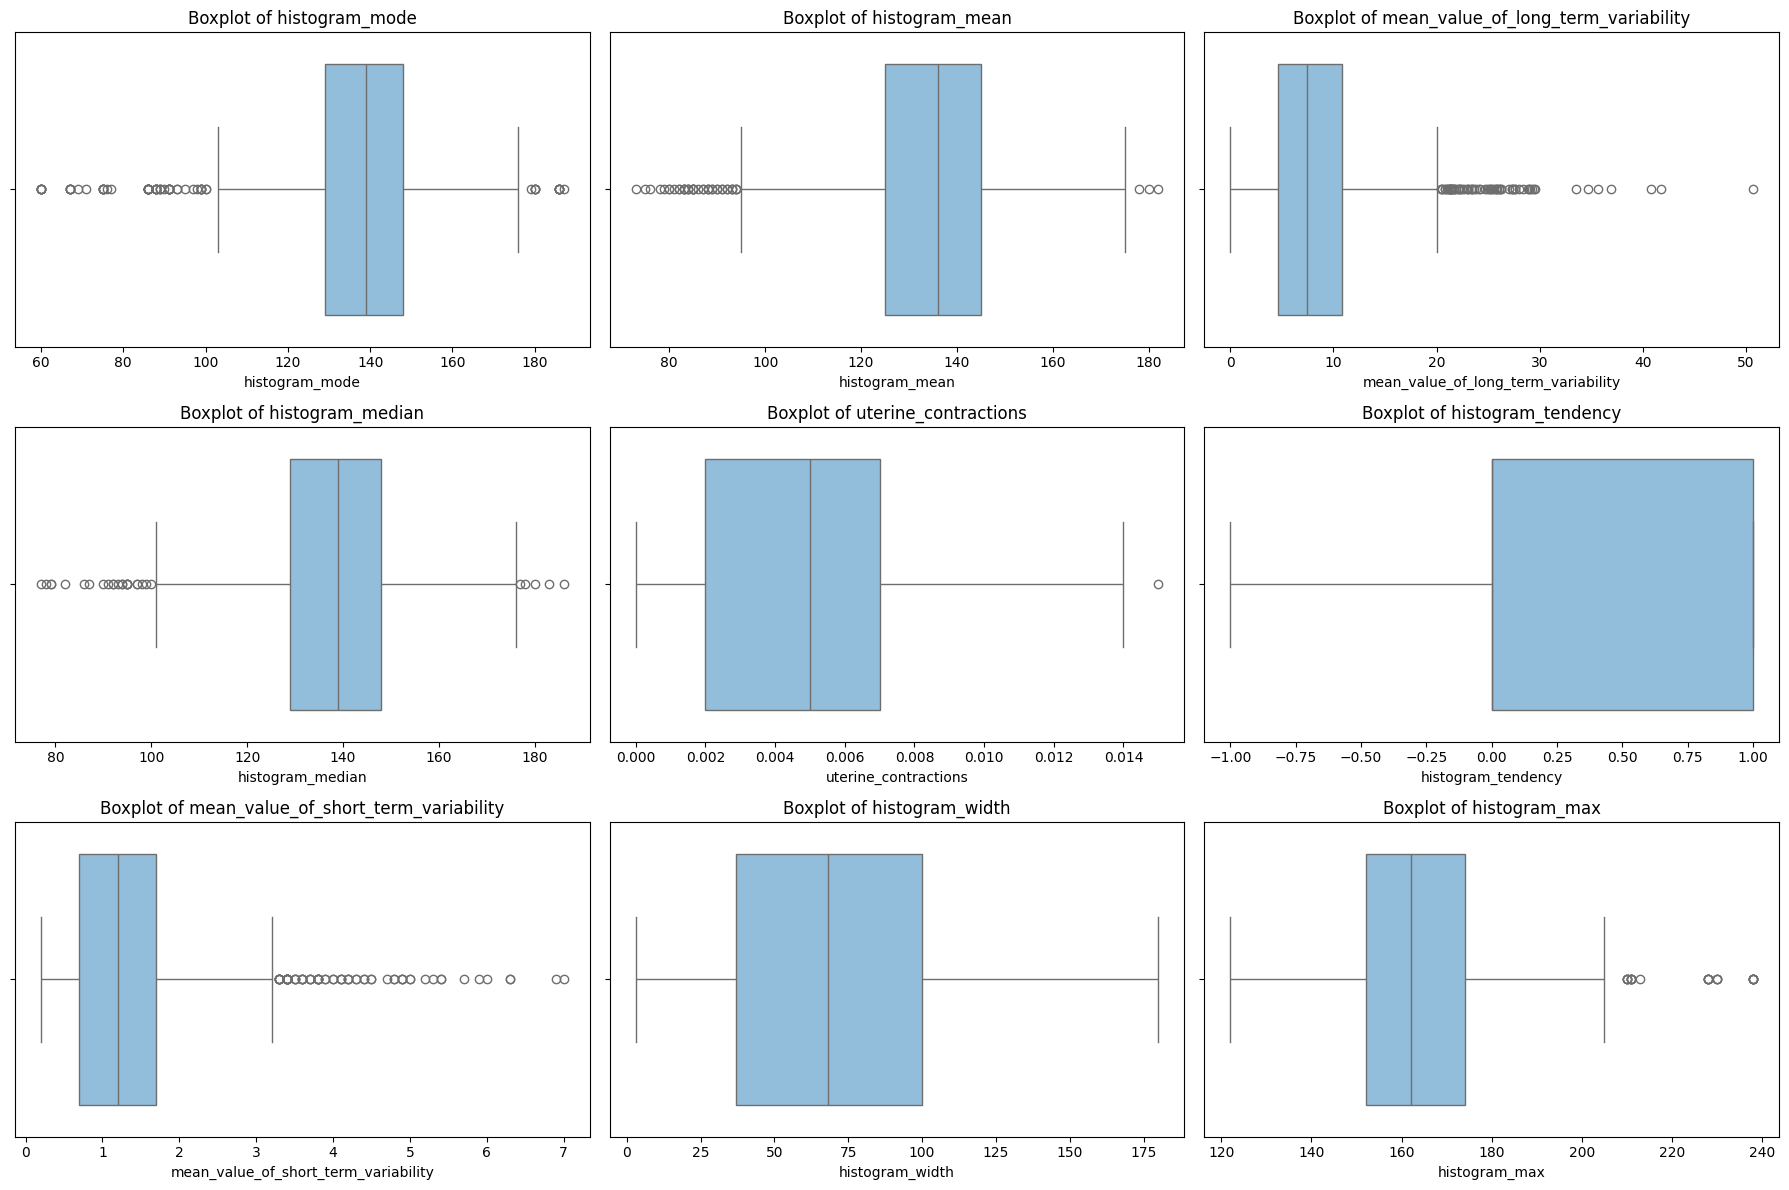

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(ax=axes[i], x=data[col], color=custom_palette[3])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# Preprosses


*   Outlliers problem
*   Unbalance target col
*   scaling data
*   test dimimantion ruduction and feature selection
*   feature engneering









**Boxplots of features after IQR capping**


In [ ]:
# outlliers IQR
iqr_capped = data.copy()
num_cols = data.select_dtypes(include=np.number).columns.drop('fetal_health') # Exclude 'fetal_health' from capping

for col in num_cols:
    Q1 = iqr_capped[col].quantile(0.25)
    Q3 = iqr_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_capped[col] = np.where(iqr_capped[col] > upper, upper,
                        np.where(iqr_capped[col] < lower, lower, iqr_capped[col]))


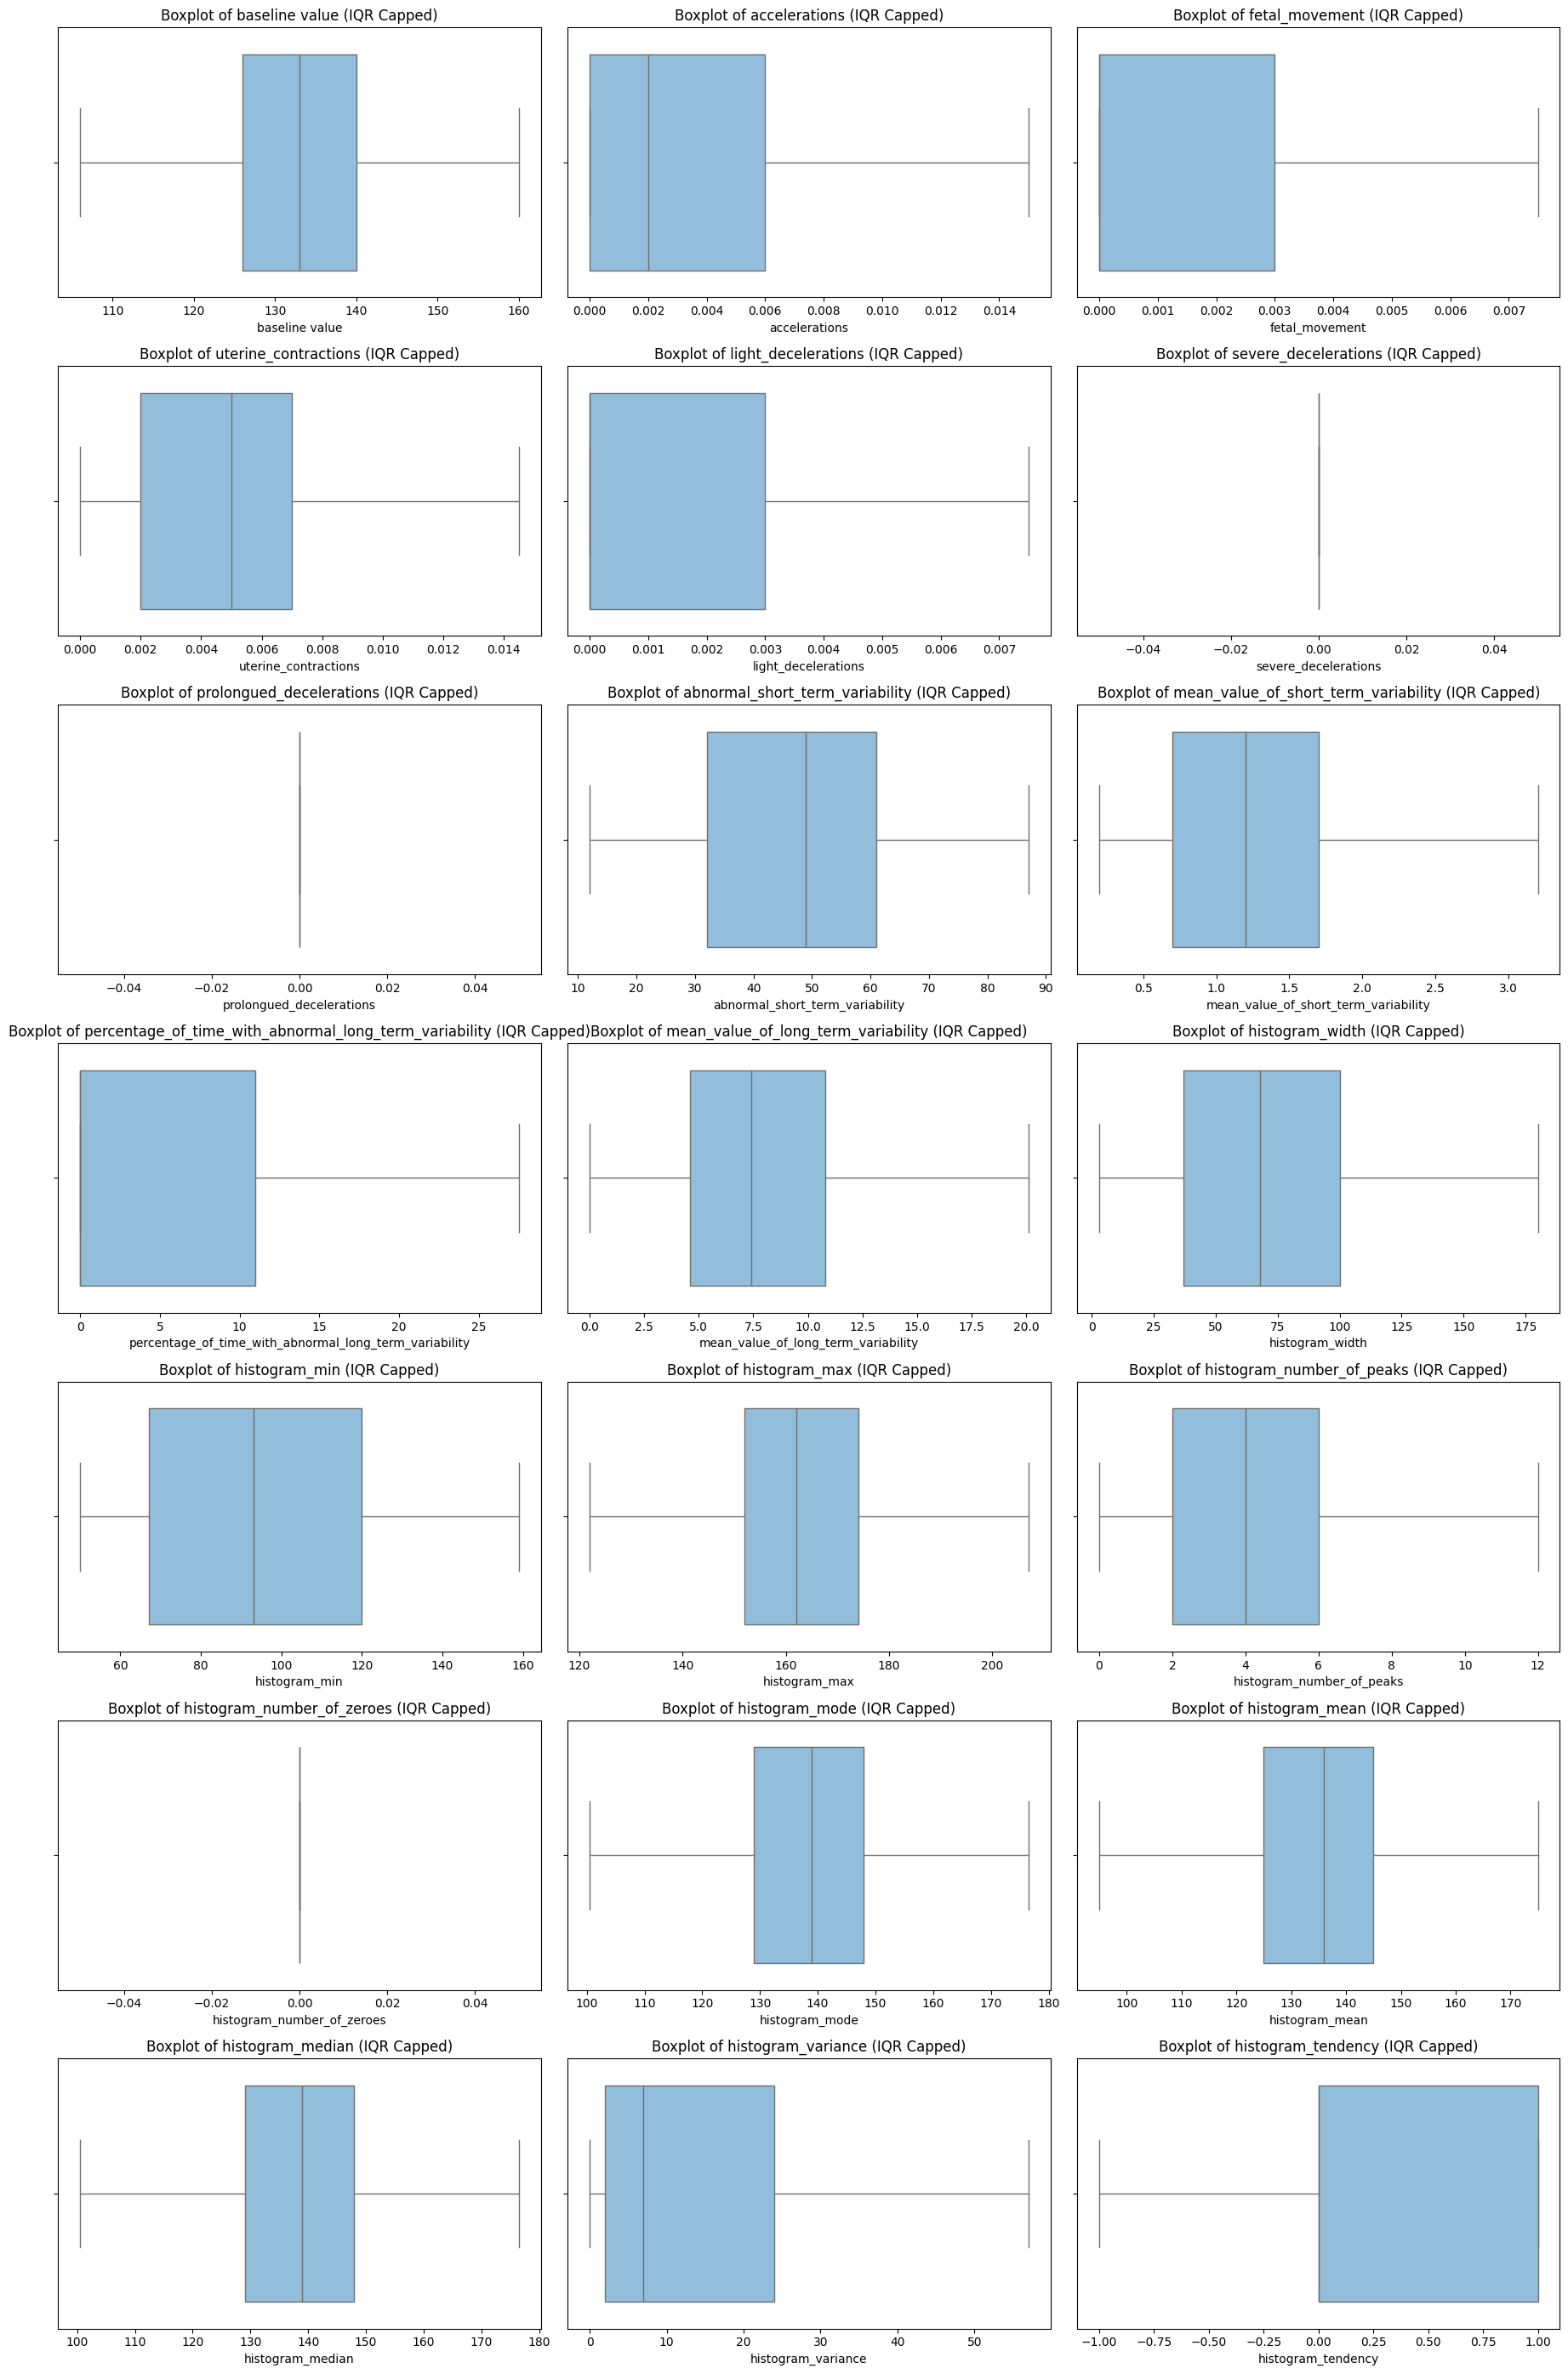

In [ ]:

num_cols = iqr_capped.select_dtypes(include=np.number).columns.drop('fetal_health')

def plot_boxplots(data, feature_cols, n_cols=3, palette_color=None, title_suffix=""):
    cols = feature_cols
    n_rows = math.ceil(len(cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        if i < len(axes):
            sns.boxplot(ax=axes[i], x=data[col], color=palette_color)
            axes[i].set_title(f"Boxplot of {col} {title_suffix}")
            axes[i].set_xlabel(col)
        else:
            break
    plt.tight_layout()
    plt.show()


plot_boxplots(iqr_capped, num_cols, palette_color=custom_palette[3], title_suffix="(IQR Capped)")


In [ ]:

print("Shape of X before SMOTETomek:", X.shape)
print("Shape of y before SMOTETomek:", y.shape)
print("Class distribution of y before SMOTETomek:\n", y.value_counts())

Shape of X before SMOTETomek: (2113, 21)
Shape of y before SMOTETomek: (2113,)
Class distribution of y before SMOTETomek:
 fetal_health
1.0    1646
2.0     292
3.0     175
Name: count, dtype: int64


In [ ]:
X = iqr_capped.drop(columns=['fetal_health'])
y = iqr_capped['fetal_health']

smotetomek = SMOTETomek(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smotetomek.fit_resample(X, y)

print("Class distribution of y after SMOTETomek:\n", y_resampled.value_counts())

Class distribution of y after SMOTETomek:
 fetal_health
3.0    1643
1.0    1642
2.0    1639
Name: count, dtype: int64


/tmp/ipython-input-2707066454.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette=custom_palette, legend=False)
/tmp/ipython-input-2707066454.py:2: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(x=y_resampled, palette=custom_palette, legend=False)


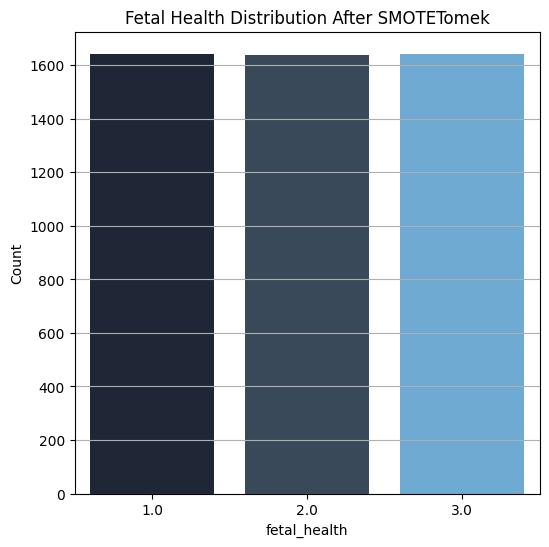

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x=y_resampled, palette=custom_palette, legend=False)
plt.grid(axis='y')
plt.title('Fetal Health Distribution After SMOTETomek')
plt.xlabel('fetal_health')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler  # test minmax scaler but result with StandardScaler is a best
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# Modeling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

## **LogisticRegression**

In [ ]:
base_model = LogisticRegression(max_iter=1000, random_state=42)
base_model.fit(X_train, y_train)
y_pred = base_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

         1.0       0.93      0.84      0.88       328
         2.0       0.79      0.89      0.84       328
         3.0       0.92      0.89      0.90       329

    accuracy                           0.88       985
   macro avg       0.88      0.88      0.88       985
weighted avg       0.88      0.88      0.88       985



In [ ]:
y_train_pred = base_model.predict(X_train)
y_test_pred = base_model.predict(X_test)

# Accuracies
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.8811881188118812
Test Accuracy: 0.8751269035532995


In [ ]:
cv_scores = cross_val_score(base_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Mean:", np.mean(cv_scores))


Cross-Validation Accuracy Mean: 0.8789078876927741
Cross-Validation Accuracy Std: 0.012919807717898668


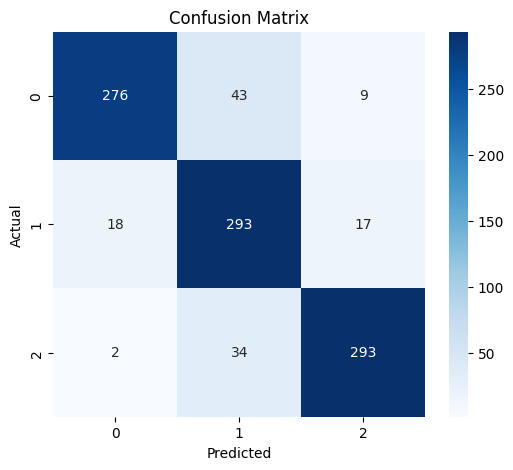

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
y_test_bin = label_binarize(y_test, classes=[1,2,3])
y_prob = base_model.predict_proba(X_test)

# AUC
auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9641547001166254


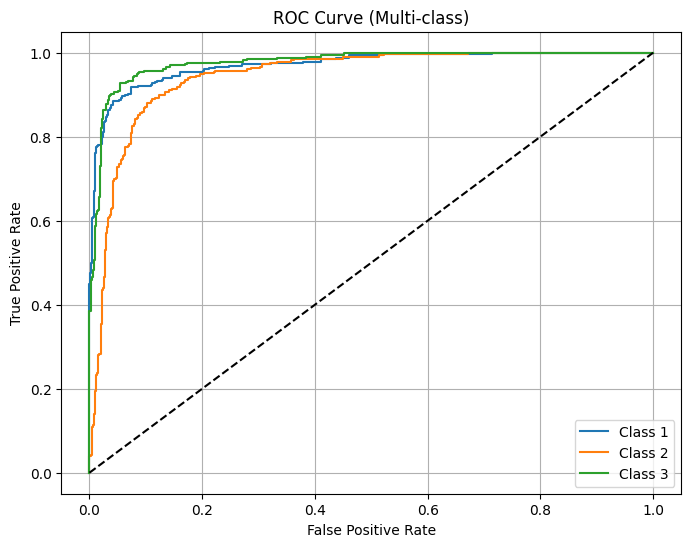

In [ ]:
plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {i+1}')

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (Multi-class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


## **KNN**

In [ ]:
knn_model=KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

         1.0       1.00      0.88      0.94       328
         2.0       0.87      0.98      0.92       328
         3.0       0.97      0.97      0.97       329

    accuracy                           0.94       985
   macro avg       0.95      0.94      0.94       985
weighted avg       0.95      0.94      0.94       985



In [ ]:
y_train_pred = knn_model.predict(X_train)
y_test_pred = knn_model.predict(X_test)

# Accuracies
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.9647118558009647
Test Accuracy: 0.9411167512690355


In [ ]:
cv_scores = cross_val_score(knn_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Mean:", np.mean(cv_scores))

Cross-Validation Accuracy Mean: 0.9294245318919756


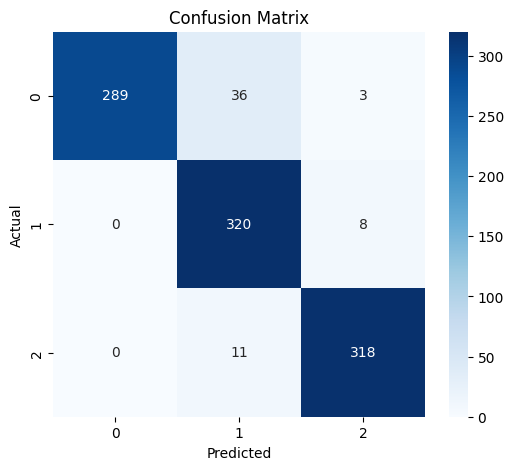

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
y_test_bin = label_binarize(y_test, classes=[1,2,3])
y_prob = knn_model.predict_proba(X_test)

# AUC
auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9884691886701452


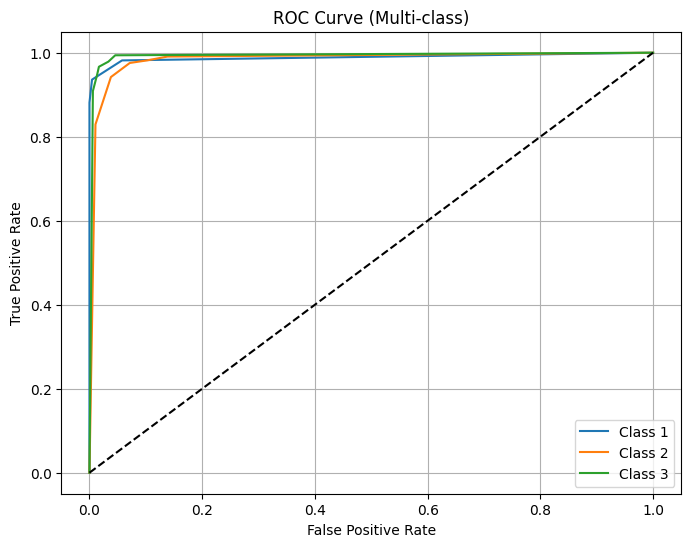

In [ ]:
plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {i+1}')

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (Multi-class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


## **NB**

In [ ]:
nb_model=GaussianNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

         1.0       0.91      0.77      0.83       328
         2.0       0.66      0.87      0.75       328
         3.0       0.81      0.67      0.74       329

    accuracy                           0.77       985
   macro avg       0.79      0.77      0.77       985
weighted avg       0.79      0.77      0.77       985



In [ ]:
y_train_pred = nb_model.predict(X_train)
y_test_pred = nb_model.predict(X_test)

# Accuracies
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.7740543285097741
Test Accuracy: 0.7715736040609137


In [ ]:
cv_scores = cross_val_score(nb_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Mean:", np.mean(cv_scores))


Cross-Validation Accuracy Mean: 0.774305174826979


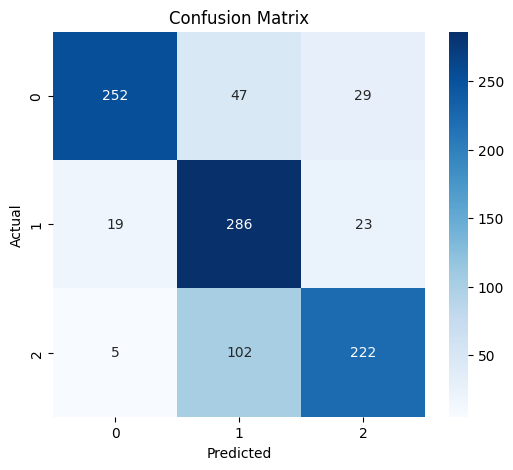

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
y_test_bin = label_binarize(y_test, classes=[1,2,3])
y_prob = nb_model.predict_proba(X_test)

# AUC
auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.8957263160177229


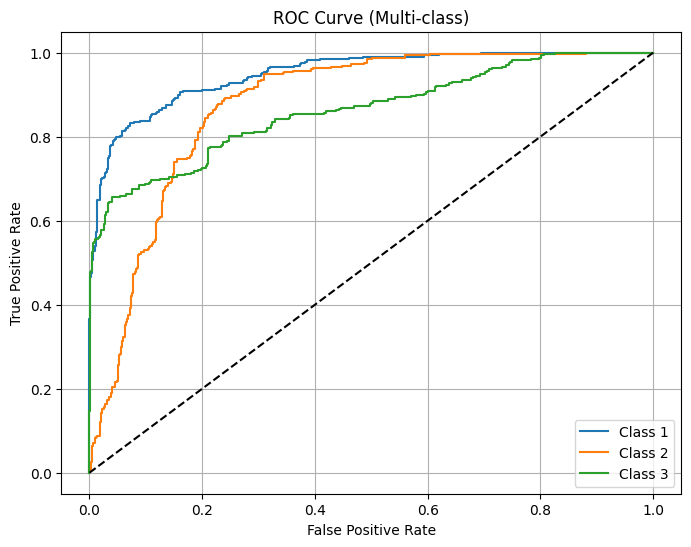

In [ ]:
plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {i+1}')

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (Multi-class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


## **SVM**

In [ ]:
svm_model=SVC()
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

         1.0       0.97      0.90      0.93       328
         2.0       0.87      0.94      0.91       328
         3.0       0.96      0.95      0.96       329

    accuracy                           0.93       985
   macro avg       0.93      0.93      0.93       985
weighted avg       0.93      0.93      0.93       985



In [ ]:
y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

# Accuracies
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy", train_acc)
print("Test Accuracy", test_acc)


Train Accuracy: 0.9372937293729373
Test Accuracy: 0.9309644670050762


In [ ]:
cv_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Mean:", np.mean(cv_scores))


Cross-Validation Accuracy Mean: 0.9251088435812923


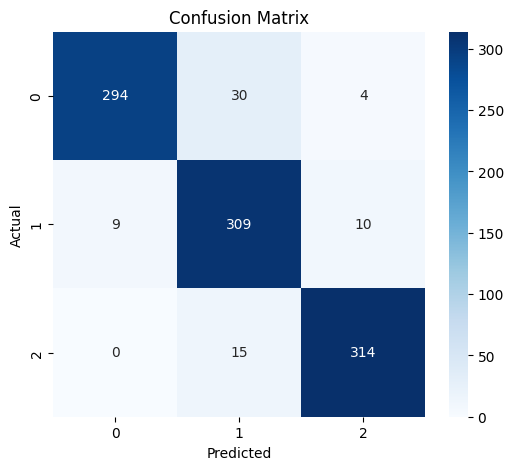

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
